In [1]:
import pandas as pd
import numpy as np
import os

# Define segments (product types) based on dataset schema
SEGMENTS = ["Contract", "General", "Perishable", "Express", "Spot"]
DATA_PATH = "../data/air_cargo_5yr_dataset.csv"

def load_oracle_time_series(origin=None, destination=None):
    """
    Loads Oracle (True Demand) time series data from the dataset.
    If origin and destination are provided, filters for that specific OD pair.
    """
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

    # Load dataset
    print(f"Loading Oracle data from {DATA_PATH}...")
    df = pd.read_csv(DATA_PATH)
    df["Date"] = pd.to_datetime(df["Date"])
    
    # Filter by OD pair if specified
    if origin and destination:
        df = df[(df["Origin"] == origin) & (df["Destination"] == destination)]
        print(f"Filtered for {origin} -> {destination}")
    
    # Extract Oracle columns for each segment
    oracle_cols = [f"Oracle_{s}_kg" for s in SEGMENTS]
    
    # Aggregate by Date (in case of multiple flights per day, though usually 1 in this synth dataset)
    ts_data = df.groupby("Date")[oracle_cols].sum()
    
    return ts_data


In [2]:
oracle_ts = load_oracle_time_series(origin="PEK", destination="LAX")

Loading Oracle data from ../data/air_cargo_5yr_dataset.csv...
Filtered for PEK -> LAX


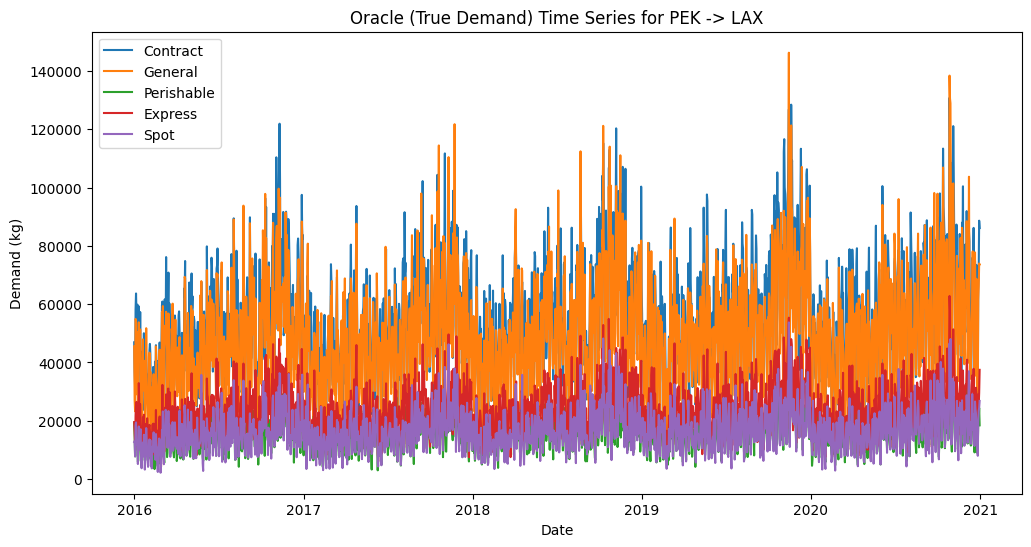

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for segment in SEGMENTS:
    plt.plot(oracle_ts.index, oracle_ts[f"Oracle_{segment}_kg"], label=segment)
plt.title("Oracle (True Demand) Time Series for PEK -> LAX")
plt.xlabel("Date")
plt.ylabel("Demand (kg)")
plt.legend()
plt.show()

In [4]:
# Import the forecaster classes from your models.py file
from base_models import NaiveForecaster, ARIMAForecaster, SARIMAForecaster

# Define the specific forecast horizons to evaluate
horizons = [1, 7, 30]
max_horizon = max(horizons)

# 1. Define the 80/20 split index
split_idx = int(len(oracle_ts) * 0.8)

# 2. Split the main dataframe chronologically
train_df = oracle_ts.iloc[:split_idx]
test_df = oracle_ts.iloc[split_idx:]

# Safety check to ensure the test set is large enough for the maximum horizon
if len(test_df) < max_horizon:
    raise ValueError(f"Test set ({len(test_df)} days) is too small for a {max_horizon}-day horizon.")

print(f"Total records: {len(oracle_ts)}")
print(f"Training on first {len(train_df)} days (80%)")
print(f"Testing horizons: {horizons} days into the test set\n")

# Dictionary to store the multi-horizon results
all_results = {}

# 3. Iterate through each section (segment column)
for segment in oracle_ts.columns:
    print(f"{'='*50}")
    print(f"Evaluating Models for: {segment}")
    print(f"{'='*50}")
    
    # Extract the arrays for training and testing
    y_train = train_df[segment].values
    y_test_full = test_df[segment].values
    
    # Initialize the models 
    models = {
        "Naive": NaiveForecaster(horizon=max_horizon),
        "ARIMA": ARIMAForecaster(order=(1, 1, 1), horizon=max_horizon),
        "SARIMA": SARIMAForecaster(order=(1, 1, 1), seasonal_order=(0, 1, 1, 7), horizon=max_horizon)
    }
    
    segment_metrics = {}
    
    # Train, predict, and evaluate each model
    for model_name, model in models.items():
        print(f"--- {model_name} ---")
        try:
            # Train on the 80% split
            model.train(y_train)
            
            # Generate a single 30-day forecast to slice from
            y_pred_full = model.predict(steps=max_horizon)
            
            model_horizon_metrics = {}
            
            # Evaluate the forecast at t=1, t=7, and t=30
            for h in horizons:
                # Slice the test data and predictions up to the current horizon 'h'
                y_test_h = y_test_full[:h]
                y_pred_h = y_pred_full[:h]
                
                # Calculate metrics for this specific timeframe
                metrics = model.evaluate(y_test_h, y_pred_h)
                model_horizon_metrics[f"t={h}"] = metrics
                
                print(f"  t={h:<2} -> RMSE: {metrics['RMSE']:>8.2f} | MAE: {metrics['MAE']:>8.2f}")
                
            segment_metrics[model_name] = model_horizon_metrics
            
        except Exception as e:
            print(f"  Failed to fit/predict. Error: {e}")
            
    all_results[segment] = segment_metrics
    print("\n")

Total records: 1827
Training on first 1461 days (80%)
Testing horizons: [1, 7, 30] days into the test set

Evaluating Models for: Oracle_Contract_kg
--- Naive ---
  t=1  -> RMSE: 14213.39 | MAE: 14213.39
  t=7  -> RMSE: 24530.50 | MAE: 21337.85
  t=30 -> RMSE: 24600.77 | MAE: 21442.58
--- ARIMA ---
  t=1  -> RMSE: 18233.45 | MAE: 18233.45
  t=7  -> RMSE: 30030.43 | MAE: 27372.18
  t=30 -> RMSE: 30469.55 | MAE: 27954.27
--- SARIMA ---
  t=1  -> RMSE: 25919.03 | MAE: 25919.03
  t=7  -> RMSE: 27412.72 | MAE: 26941.23
  t=30 -> RMSE: 30572.21 | MAE: 29179.97


Evaluating Models for: Oracle_General_kg
--- Naive ---
  t=1  -> RMSE: 26450.71 | MAE: 26450.71
  t=7  -> RMSE: 38817.96 | MAE: 37046.93
  t=30 -> RMSE: 36508.11 | MAE: 34321.47
--- ARIMA ---
  t=1  -> RMSE: 21382.73 | MAE: 21382.73
  t=7  -> RMSE: 32173.88 | MAE: 30111.57
  t=30 -> RMSE: 29724.61 | MAE: 27007.03
--- SARIMA ---
  t=1  -> RMSE: 30517.18 | MAE: 30517.18
  t=7  -> RMSE: 33111.50 | MAE: 32632.80
  t=30 -> RMSE: 32101.30 